# Efficiency and Fairness per model

In [28]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from Classes.bar import Bar
from Config.config import PATHS

In [29]:
def plot_stability(list_of_alternations, list_of_titles, num_rounds):
	fig, axes = plt.subplots(len(list_of_alternations))
	for i, alternations in enumerate(list_of_alternations):
		# Detect number of agents
		num_agents = len(alternations[0])
		# Create bar object
		bar = Bar(
			num_agents=num_agents,
			threshold=0.5
		)
		bar.history = alternations * (num_rounds // len(alternations)) + alternations[:num_rounds % len(alternations)]
		attendance_file_name = None #'alternations.png'
		bar.render(
			ax=axes[i],
			file=attendance_file_name,
			num_rounds=len(bar.history)
		)
#		axes[i].imshow(plt.imread(attendance_file_name))
		if list_of_titles is not None:
			axes[i].set_title(list_of_titles[i])
		axes[i].axis('off')
	return fig


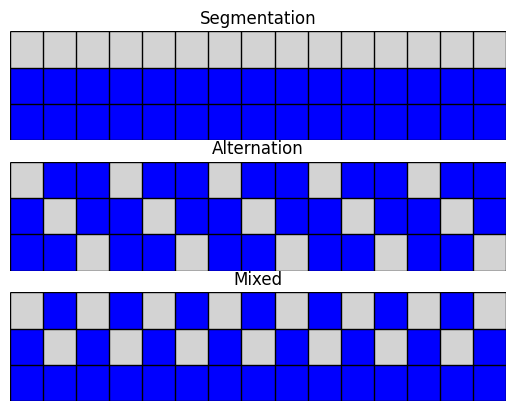

In [30]:
num_rounds = 15
list_of_alternations = [
	# [np.random.randint(0, 2, 3).tolist() for _ in range(num_rounds)],
	[[1, 1, 0]],
	[[1, 1, 0], [1, 0, 1], [0, 1, 1]],
	[[1, 1, 0], [1, 0, 1]],
]
fig = plot_stability(
    list_of_alternations=list_of_alternations, 
    list_of_titles = ['Segmentation', 'Alternation', 'Mixed'],
    num_rounds=num_rounds
)
fig.savefig(PATHS['exploratory_figures'] / 'Coordination_types.png', dpi=300)

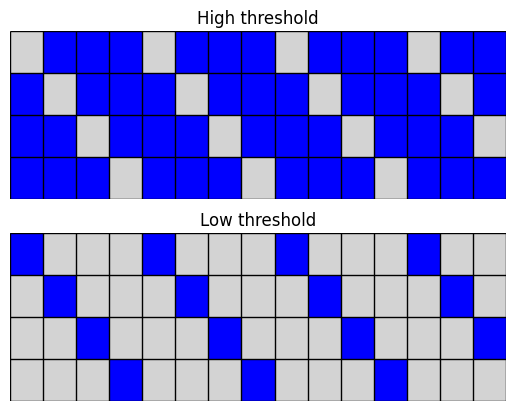

In [31]:
num_rounds = 15
list_of_alternations = [
	[[1, 1, 1, 0], [1, 1, 0, 1], [1, 0, 1, 1], [0, 1, 1, 1]],
	[[0, 0, 0, 1], [0, 0, 1, 0], [0, 1, 0, 0], [1, 0, 0, 0]],
]
fig = plot_stability(
    list_of_alternations=list_of_alternations, 
    list_of_titles = ['High threshold', 'Low threshold'],
    num_rounds=num_rounds
)
fig.savefig(PATHS['exploratory_figures'] / 'Symmetry_of_coordination.png', dpi=300)

/var/folders/45/0nlf84vn0hsfyvm8y9gzf6cc0000gn/T/ipykernel_5804/1011705264.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


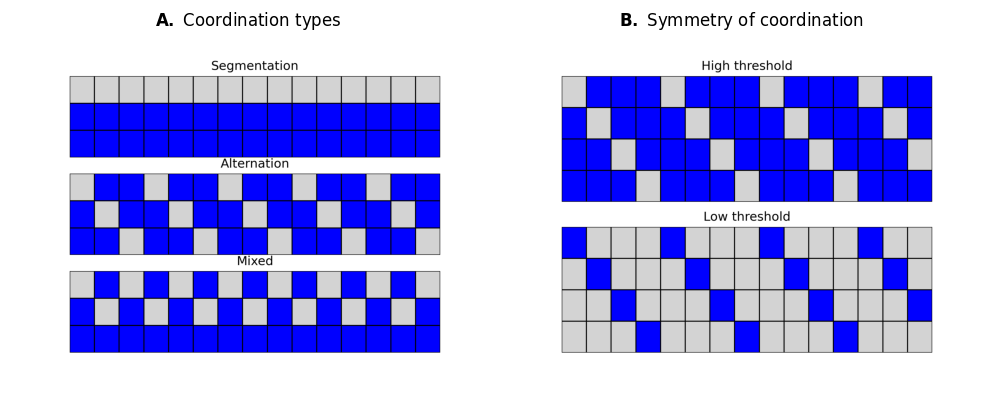

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(plt.imread(PATHS['exploratory_figures'] / 'Coordination_types.png'))
axes[0].set_title(r'$\bf{A.}$ Coordination types')
axes[1].imshow(plt.imread(PATHS['exploratory_figures'] / 'Symmetry_of_coordination.png'))
axes[1].set_title(r'$\bf{B.}$ Symmetry of coordination')
for ax in axes:
    ax.axis('off')
fig.tight_layout()
fig.savefig(PATHS['exploratory_figures'] / 'Fig1.png', dpi=300)
fig.show()

In [33]:
from Utils.cherrypick_simulations import CherryPickEquilibria

num_agents = 6
threshold = 0.34
kind = 'segmentation'

equilibria = CherryPickEquilibria(
    num_agents=num_agents,
    threshold = threshold,
    epsilon=0.01,
    num_rounds=50,
    num_episodes=30,
    allow_shuffle=True,
)

df = equilibria.generate_data(kind)


Running episodes:   0%|          | 0/30 [00:00<?, ?it/s]

In [34]:
from Utils.utils import GetMeasurements

gm = GetMeasurements(
    data=df,
    measures=['bounded_efficiency', 'gini_index', 'min_entropy']
)
gm.columns.append('kind')
df_measures = gm.get_measurements()

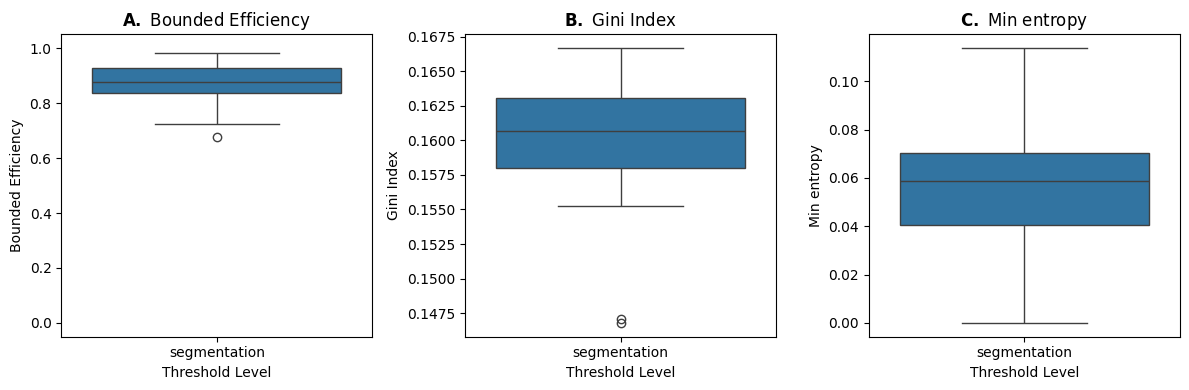

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), tight_layout=True)

sns.boxplot(
    data=df_measures,
    x="kind",
    y="bounded_efficiency",
    ax=ax[0],
)
ax[0].set_ylim(-0.05, 1.05)
ax[0].set_title(r"$\bf{A.}$ Bounded Efficiency")
ax[0].set_xlabel("Threshold Level")
ax[0].set_ylabel("Bounded Efficiency")

sns.boxplot(
    data=df_measures,
    x="kind",
    y="gini_index",
    ax=ax[1],
)
ax[1].set_ylim(-0.05, 1.05)
ax[1].set_title(r"$\bf{B.}$ Gini Index")
ax[1].set_xlabel("Threshold Level")
ax[1].set_ylabel("Gini Index")

sns.boxplot(
    data=df_measures,
    x="kind",
    y="min_entropy",
    ax=ax[2],
)
# ax[2].set_ylim(-0.05, 0.3)
ax[2].set_title(r"$\bf{C.}$ Min entropy")
ax[2].set_xlabel("Threshold Level")
ax[2].set_ylabel("Min entropy")

plt.show()